**Data Collection**

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
#Dataset collection from the website
#read the csv file and assign it to dataframe called df
df = pd.read_csv('/content/drive/MyDrive/cancer_prediction.csv')

#print the dataframe
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


**Data Pre-Processing**

In [23]:
# Drop columns that are entirely NaN (like 'Unnamed: 32')
df = df.dropna(axis=1, how='all')

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with any remaining NaN values
df = df.dropna()

df.info()

df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [24]:
df = df.drop('id', axis=1)
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [25]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

print("Checking for categorical columns to label encode...")

# Check if 'diagnosis' column still needs encoding
if df['diagnosis'].dtype == 'object':
    print("Label encoding 'diagnosis' column...")
    le = LabelEncoder()
    df['diagnosis'] = le.fit_transform(df['diagnosis'])
    print("DataFrame head after Label Encoding:")
    print(df.head())
    print("\nValue counts for 'diagnosis' after encoding:")
    print(df['diagnosis'].value_counts())
else:
    print("'diagnosis' column is already numerically encoded.")
    print("DataFrame head:")
    print(df.head())
    print("\nValue counts for 'diagnosis':")
    print(df['diagnosis'].value_counts())

# Check for any other remaining object type columns
object_cols = df.select_dtypes(include='object').columns
if len(object_cols) > 0:
    print(f"\nOther categorical columns detected: {list(object_cols)}. Applying Label Encoding to them.")
    for col in object_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
    print("DataFrame head after encoding all categorical columns:")
    print(df.head())
else:
    print("\nNo other categorical columns detected in the DataFrame.")

Checking for categorical columns to label encode...
Label encoding 'diagnosis' column...
DataFrame head after Label Encoding:
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.

In [26]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (398, 30)
X_test shape: (171, 30)
y_train shape: (398,)
y_test shape: (171,)


In [27]:
from scipy import stats
import numpy as np

# Identify numerical columns in X_train (excluding the target column which is in y_train)
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Calculate Z-scores for numerical columns in X_train
z = np.abs(stats.zscore(X_train[numerical_cols]))

# Define a threshold for outliers (e.g., 3 standard deviations)
threshold = 3

# Find indices of rows with outliers
outlier_indices = np.where(z > threshold)[0]

# Remove outliers from X_train and y_train
X_train_cleaned = X_train.drop(X_train.index[np.unique(outlier_indices)])
y_train_cleaned = y_train.drop(y_train.index[np.unique(outlier_indices)])

print(f"Original X_train shape: {X_train.shape}")
print(f"Cleaned X_train shape: {X_train_cleaned.shape}")
print(f"Number of outliers removed: {X_train.shape[0] - X_train_cleaned.shape[0]}")

X_train = X_train_cleaned
y_train = y_train_cleaned

Original X_train shape: (398, 30)
Cleaned X_train shape: (347, 30)
Number of outliers removed: 51


In [28]:
print("X_train after outlier removal:")
display(X_train)
print("\ny_train after outlier removal:")
display(y_train)

X_train after outlier removal:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
330,16.03,15.51,105.80,793.2,0.09491,0.13710,0.12040,0.07041,0.1782,0.05976,...,18.76,21.98,124.30,1070.0,0.14350,0.44780,0.49560,0.19810,0.3019,0.09124
378,13.66,15.15,88.27,580.6,0.08268,0.07548,0.04249,0.02471,0.1792,0.05897,...,14.54,19.64,97.96,657.0,0.12750,0.31040,0.25690,0.10540,0.3387,0.09638
89,14.64,15.24,95.77,651.9,0.11320,0.13390,0.09966,0.07064,0.2116,0.06346,...,16.34,18.24,109.40,803.6,0.12770,0.30890,0.26040,0.13970,0.3151,0.08473
32,17.02,23.98,112.80,899.3,0.11970,0.14960,0.24170,0.12030,0.2248,0.06382,...,20.88,32.09,136.10,1344.0,0.16340,0.35590,0.55880,0.18470,0.3530,0.08482
240,13.64,15.60,87.38,575.3,0.09423,0.06630,0.04705,0.03731,0.1717,0.05660,...,14.85,19.05,94.11,683.4,0.12780,0.12910,0.15330,0.09222,0.2530,0.06510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,13.03,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.02923,0.1467,0.05863,...,13.30,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169
415,11.89,21.17,76.39,433.8,0.09773,0.08120,0.02555,0.02179,0.2019,0.06290,...,13.05,27.21,85.09,522.9,0.14260,0.21870,0.11640,0.08263,0.3075,0.07351
458,13.00,25.13,82.61,520.2,0.08369,0.05073,0.01206,0.01762,0.1667,0.05449,...,14.34,31.88,91.06,628.5,0.12180,0.10930,0.04462,0.05921,0.2306,0.06291
476,14.20,20.53,92.41,618.4,0.08931,0.11080,0.05063,0.03058,0.1506,0.06009,...,16.45,27.26,112.10,828.5,0.11530,0.34290,0.25120,0.13390,0.2534,0.07858



y_train after outlier removal:


,diagnosis
330,1
378,0
89,0
32,1
240,0
...,...
37,0
415,0
458,0
476,0


**Data Modelling**

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest Classifier
# Using a random_state for reproducibility
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the cleaned training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Random Forest Classifier Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)


Random Forest Classifier Accuracy: 0.9708

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [30]:
from sklearn.metrics import roc_auc_score

# Calculate AUC for Random Forest Classifier
rf_auc = roc_auc_score(y_test, rf_classifier.predict_proba(X_test)[:, 1])
print(f"Random Forest AUC: {rf_auc:.4f})")


Random Forest AUC: 0.9953)


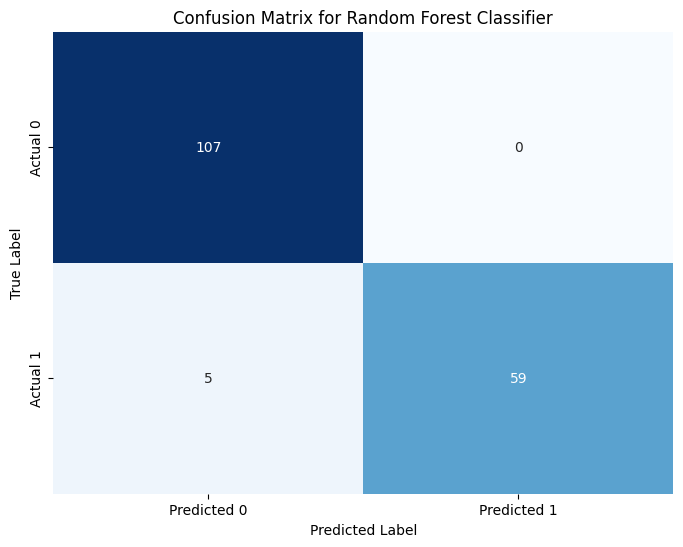

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

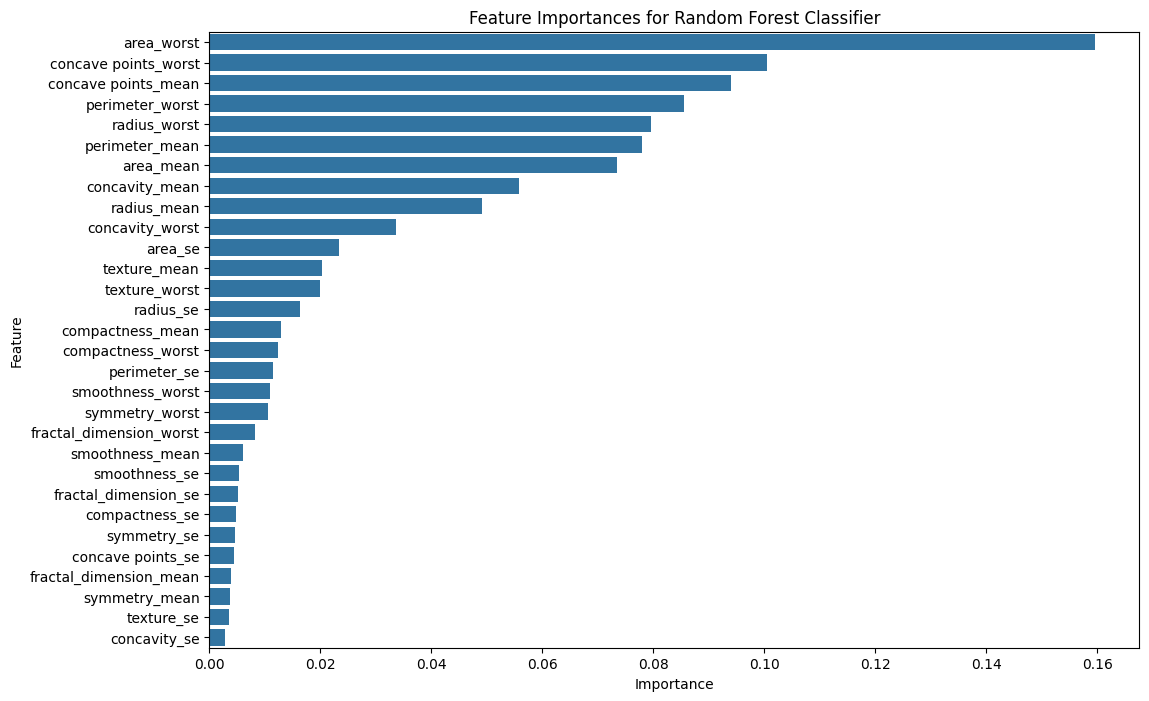

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest classifier
feature_importances = rf_classifier.feature_importances_

# Create a pandas Series for easier handling and plotting
features_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importances for Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Dictionary to store model performances
model_performance = {}

# --- Random Forest (already trained) ---
# The rf_classifier is already trained and evaluated in a previous cell.
# I'll just retrieve its accuracy and report.
rf_accuracy = accuracy_score(y_test, y_pred)
model_performance['Random Forest'] = {'Accuracy': rf_accuracy, 'Report': classification_report(y_test, y_pred, output_dict=True)}
print(f"Random Forest Classifier Accuracy: {rf_accuracy:.4f}")
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred))

# --- Decision Tree Classifier ---
print("\n--- Training Decision Tree Classifier ---")
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
model_performance['Decision Tree'] = {'Accuracy': dt_accuracy, 'Report': classification_report(y_test, y_pred_dt, output_dict=True)}
print(f"Decision Tree Classifier Accuracy: {dt_accuracy:.4f}")
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))

# --- Logistic Regression Classifier ---
print("\n--- Training Logistic Regression Classifier ---")
# Increased max_iter to ensure convergence
lr_classifier = LogisticRegression(random_state=42, max_iter=1000)
lr_classifier.fit(X_train, y_train)
y_pred_lr = lr_classifier.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
model_performance['Logistic Regression'] = {'Accuracy': lr_accuracy, 'Report': classification_report(y_test, y_pred_lr, output_dict=True)}
print(f"Logistic Regression Classifier Accuracy: {lr_accuracy:.4f}")
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))

# --- Naive Bayes Classifier (Gaussian Naive Bayes) ---
print("\n--- Training Naive Bayes Classifier ---")
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
y_pred_nb = nb_classifier.predict(X_test)
nb_accuracy = accuracy_score(y_test, y_pred_nb)
model_performance['Naive Bayes'] = {'Accuracy': nb_accuracy, 'Report': classification_report(y_test, y_pred_nb, output_dict=True)}
print(f"Naive Bayes Classifier Accuracy: {nb_accuracy:.4f}")
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))

# --- Comparison of Models ---
print("\n--- Model Comparison ---")
comparison_df = pd.DataFrame({
    'Model': list(model_performance.keys()),
    'Accuracy': [data['Accuracy'] for data in model_performance.values()]
})
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print(comparison_df)

Random Forest Classifier Accuracy: 0.9708
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171


--- Training Decision Tree Classifier ---
Decision Tree Classifier Accuracy: 0.9064
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       107
           1       0.90      0.84      0.87        64

    accuracy                           0.91       171
   macro avg       0.90      0.89      0.90       171
weighted avg       0.91      0.91      0.91       171


--- Training Logistic Regression Classifier ---
Logistic Regression Classifier Accuracy: 0.9415
Logistic Regression Classification Report:
   

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/tmp/ipykernel_819/1128629753.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')


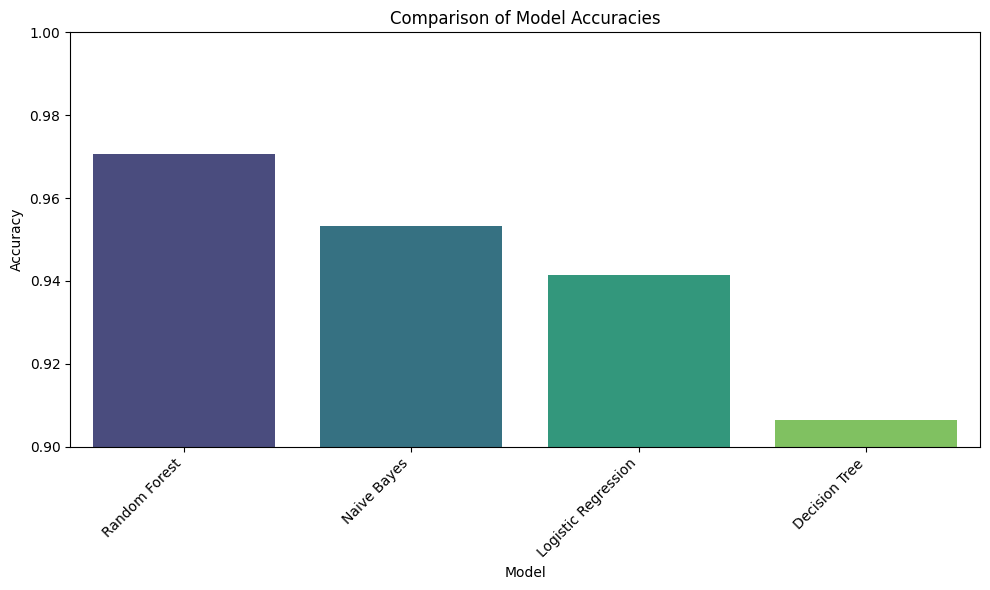

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0) # Set y-axis limits to better visualize differences
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

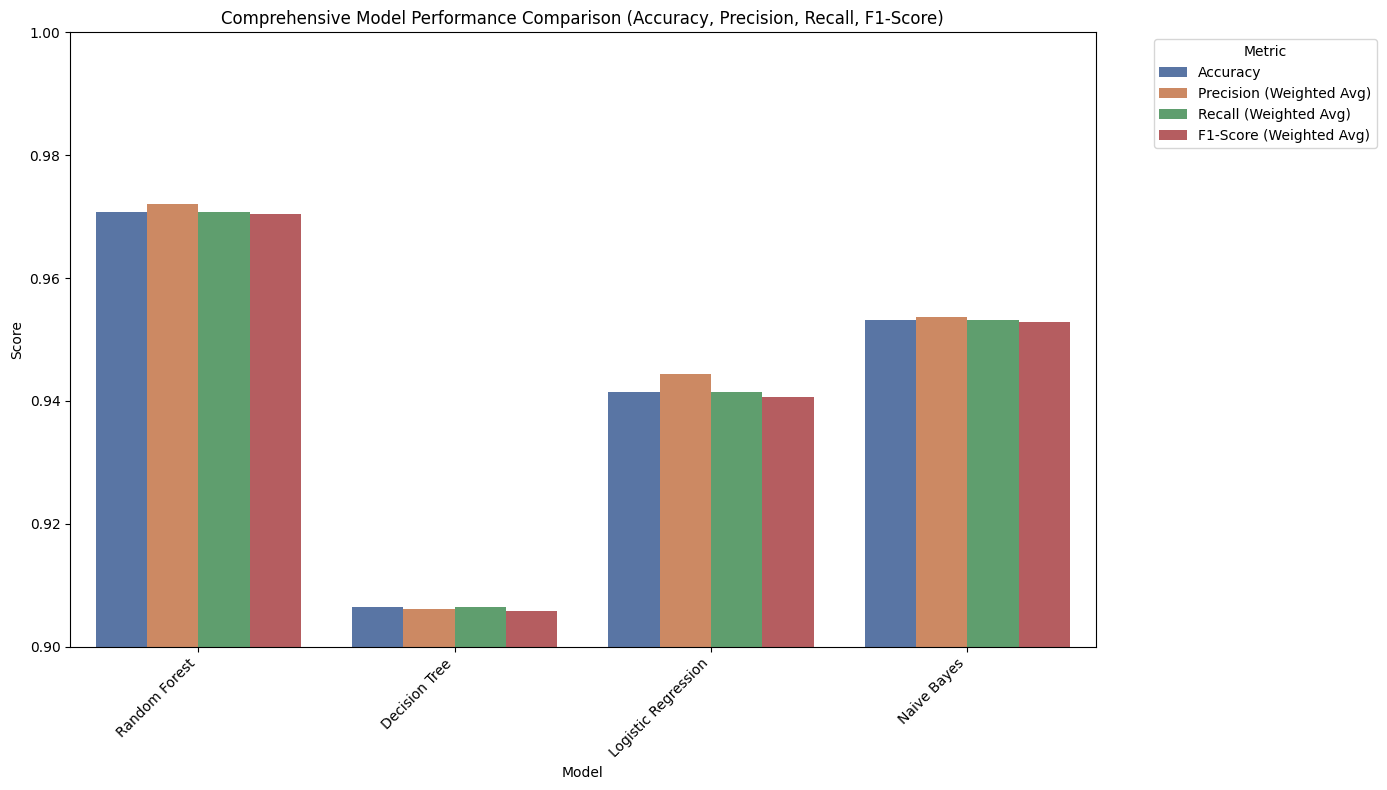

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for detailed comparison chart
detailed_metrics = []
for model_name, data in model_performance.items():
    accuracy = data['Accuracy']
    report_dict = data['Report']

    # Using 'weighted avg' for combined precision, recall, f1-score due to potential class imbalance
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']

    detailed_metrics.append({
        'Model': model_name,
        'Metric': 'Accuracy',
        'Value': accuracy
    })
    detailed_metrics.append({
        'Model': model_name,
        'Metric': 'Precision (Weighted Avg)',
        'Value': precision
    })
    detailed_metrics.append({
        'Model': model_name,
        'Metric': 'Recall (Weighted Avg)',
        'Value': recall
    })
    detailed_metrics.append({
        'Model': model_name,
        'Metric': 'F1-Score (Weighted Avg)',
        'Value': f1_score
    })

df_detailed = pd.DataFrame(detailed_metrics)

# Create the grouped bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='Value', hue='Metric', data=df_detailed, palette='deep')
plt.title('Comprehensive Model Performance Comparison (Accuracy, Precision, Recall, F1-Score)')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0.9, 1.0) # Adjust y-axis for better visual comparison of high scores
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Cross-Validation of Models

In [36]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import pandas as pd

# Prepare models in a dictionary
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB()
}

# Prepare KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store cross-validation results
cv_results = {}

print("Performing K-Fold Cross-Validation (5 Folds)...")

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    try:
        scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
        cv_results[name] = {
            'Mean Accuracy': np.mean(scores),
            'Std Deviation': np.std(scores) # Corrected from np.np.std
        }
        print(f"  Mean Accuracy: {np.mean(scores):.4f}")
        print(f"  Standard Deviation: {np.std(scores):.4f}")
    except Exception as e:
        print(f"  Error evaluating {name}: {e}")
        cv_results[name] = {'Mean Accuracy': np.nan, 'Std Deviation': np.nan}

# Create a DataFrame for easy comparison
cv_df = pd.DataFrame(cv_results).T # Transpose to have models as rows
cv_df = cv_df.sort_values(by='Mean Accuracy', ascending=False)

print("\nCross-Validation Results:")
display(cv_df)


Performing K-Fold Cross-Validation (5 Folds)...

Evaluating Random Forest...
  Mean Accuracy: 0.9596
  Standard Deviation: 0.0105

Evaluating Decision Tree...
  Mean Accuracy: 0.9332
  Standard Deviation: 0.0162

Evaluating Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

  Mean Accuracy: 0.9437
  Standard Deviation: 0.0227

Evaluating Naive Bayes...
  Mean Accuracy: 0.9385
  Standard Deviation: 0.0201

Cross-Validation Results:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Mean Accuracy,Std Deviation
Random Forest,0.959587,0.010496
Logistic Regression,0.943720,0.022746
Naive Bayes,0.938457,0.020127
Decision Tree,0.933225,0.016236
